In [9]:
import tensorflow as tf
from keras import layers, Model
import matplotlib.pyplot as plt

Tensorflow is a deep learning framework required to build the deep learning models.

Keras : In order to develop the framework, we need layers, models . So we need keras.

In [10]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()   # no need of x_test and y_test.
x_train = x_train.astype('float32') / 255.0    # data is getting normalized between 0 & 1
x_test = x_test.astype('float32') / 255.0

print(x_train.shape, x_test.shape)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)   # converting 28*28 into 784.

print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


**Sampling Layer**

In [13]:
latent_dim = 16   # dimension of latent space

class Sampling(layers.Layer):
  def call(self, inputs):
    z_mean, z_log_var = inputs

    epsilon = tf.random.normal(
        shape = tf.shape(z_mean)
    )
    return z_mean+tf.exp(0.5 * z_log_var) * epsilon

**Encoder**

In [14]:
encoder_inputs = layers.Input(shape=(784,))

X = layers.Dense(256, activation='relu')(encoder_inputs)
z_mean = layers.Dense(latent_dim, name='z_mean')(X)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(X)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="Encoder")

**Decoder**

In [15]:

latent_inputs = layers.Input(shape=(latent_dim,))

X = layers.Dense(256, activation='relu')(latent_inputs)
decoder_outputs = layers.Dense(784, activation='sigmoid')(X)

decoder = Model(latent_inputs, decoder_outputs, name='Decoder')

**VAE Model**

In [16]:
class VAE(Model):
  def __init__(self, encoder, decoder):
    super().__init__()

    self.encoder = encoder
    self.decoder = decoder

  def call(self, inputs):
    z_mean, z_log_var, z = self.encoder(inputs)
    reconstruction = self.decoder(z)
    return reconstruction

  def train_step(self, data):
    if isinstance(data, tuple):
      data = data[0]

    with tf.GradientTape() as tape:
      z_mean, z_log_var, z= self.encoder(data)
      reconstruction = self.decoder(z)

      # Reconstruction loss
      reconstruction_loss = tf.reduce_mean(
              tf.keras.losses.binary_crossentropy(data, reconstruction),
          )
      # KL Divergence

      kl_loss = -0.5*tf.reduce_mean(
          1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
      )
      # Total Loss
      total_loss = reconstruction_loss + kl_loss

    grads = tape.gradient(total_loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

    return{
        "loss": total_loss,
        "reconstruction_loss": reconstruction_loss,
        "kl_loss": kl_loss
    }

**Create VAE**

In [18]:
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

**Train VAE**

In [19]:
history = vae.fit(x_train, epochs=30, batch_size=128)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - kl_loss: 1.8740e-04 - loss: 0.2636 - reconstruction_loss: 0.2634
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 2.6079e-04 - loss: 0.2691 - reconstruction_loss: 0.2688
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 2.8414e-04 - loss: 0.2724 - reconstruction_loss: 0.2721
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 2.3728e-04 - loss: 0.2674 - reconstruction_loss: 0.2672
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 1.1539e-04 - loss: 0.2634 - reconstruction_loss: 0.2633
Epoch 6/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 1.1482e-04 - loss: 0.2696 - reconstruction_loss: 0.2695
Epoch 7/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - kl_loss: 4.2324e-05 - loss: 0.2611 - reconstruction_loss: 0.2610
Epoch 8/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 3.6466e-05 - loss: 0.2665 - reconstruction_loss: 0.2665
Epoch 9/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8m

**Reconstruct Test Images**

In [21]:
z_mean, z_log_var, z = encoder.predict(x_test[:10])
reconstructed = decoder.predict(z)
reconstructed.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


(10, 784)

**Plotting Original vs Reconstruction**

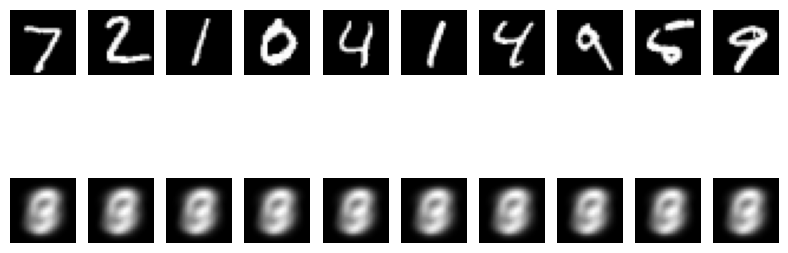

In [22]:
plt.figure(figsize=(20,4))

for i in range(10):

  #Original
  ax = plt.subplot(2, 20, i+1)
  plt.imshow(x_test[i].reshape(28,28), cmap = "grey")
  plt.axis("off")

  #Reconstructed
  ax = plt.subplot(2, 20, i+21)
  plt.imshow(reconstructed[i].reshape(28,28), cmap = "grey")
  plt.axis("off")

plt.show()